In [ ]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# import torch
# import torch.nn as nn

# from sklearn.metrics import confusion_matrix
# import plotly.express as px


In [ ]:
# import sys, os
# while not os.path.isdir('src') and os.path.dirname(os.getcwd()) != os.getcwd():
#     os.chdir('..')
# sys.path.insert(0, 'src')

# import numpy as np, json
# import matplotlib.pyplot as plt
# os.makedirs('dashboard/data', exist_ok=True)

# from tradinglab.data_feed import DataFeed
# from tradinglab.features import feature_columns, FEATURE_NAMES

# EPOCHS = 150
# COMMISSION = 0.00
# TOP_K = 4

# feed = DataFeed.from_dir('data/egx')
# # feed = DataFeed.from_dir('data/egx', symbols=['COMI', 'HRHO', 'TMGH', 'SWDY', 'FWRY', 'ABUK'])
# # feed = DataFeed.from_dir('data/egx', symbols=['ABUK'])

# X0 = feature_columns(feed, asset=0)   # the feature table for the first stock
# print('stock:', feed.symbols[0])
# print('columns (your week-1 indicators):', FEATURE_NAMES)
# print('a real row (day 100):', np.round(X0[100], 3))

stock: ABUK
columns (your week-1 indicators): ['return', 'p/sma_fast', 'p/sma_slow', 'rsi', 'volatility', 'macd_hist', 'return_5d', 'return_10d', 'volume_ratio']
a real row (day 100): [0.006 0.041 0.068 0.867 0.013]


In [ ]:
# from tradinglab.features import build_pooled_dataset
# import torch

# # 70% of the calendar days for training
# split_day = int(feed.n_days * 0.7)

# # IMPORTANT: the function returns FOUR values
# X_train, y_train, X_test, y_test = build_pooled_dataset(
#     feed,
#     split_day
# )

# # Convert to PyTorch tensors
# Xtr = torch.tensor(X_train, dtype=torch.float32)
# ytr = torch.tensor(y_train, dtype=torch.float32)

# Xte = torch.tensor(X_test, dtype=torch.float32)
# yte = torch.tensor(y_test, dtype=torch.float32)

# print("Xtr:", Xtr.shape)
# print("ytr:", ytr.shape)
# print("Xte:", Xte.shape)
# print("yte:", yte.shape)

d:\EFG\2026-orion\src\tradinglab\features.py:64: RuntimeWarning: invalid value encountered in divide
  volume_ratio = volume / vol_avg20


Xtr: torch.Size([26588, 5])
ytr: torch.Size([26588])
Xte: torch.Size([11798, 5])
yte: torch.Size([11798])


In [ ]:
# import torch
# import torch.nn as nn

# model = nn.Sequential(
#     nn.Linear(5, 32),
#     nn.ReLU(),
#     nn.Linear(32, 1)
# )

# criterion = nn.BCEWithLogitsLoss()
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# model.train()

# optimizer.zero_grad()

# train_logits = model(Xtr).squeeze(1)

# train_loss = criterion(train_logits, ytr)

# train_loss.backward()
# optimizer.step()

# print("Training loss:", train_loss.item())

Training loss: 0.7585675120353699


In [ ]:
# model.eval()

# with torch.no_grad():
#     test_logits = model(Xte).squeeze(1)
    
#     test_loss = criterion(test_logits, yte)

#     predictions = (torch.sigmoid(test_logits) >= 0.5).float()
#     accuracy = (predictions == yte).float().mean()

# print("Test loss:", test_loss.item())
# print("Test accuracy:", accuracy.item())

Test loss: 0.7551281452178955
Test accuracy: 0.0


In [ ]:
# print("=== LABEL DISTRIBUTION ===")

# print("ytr:")
# print(torch.unique(ytr, return_counts=True))

# print("\nyte:")
# print(torch.unique(yte, return_counts=True))

# print("\n=== PREDICTION DISTRIBUTION ===")

# print("predictions:")
# print(torch.unique(predictions, return_counts=True))

# print("\n=== FIRST 20 ===")

# print("Actual:   ", yte[:20])
# print("Predicted:", predictions[:20])

=== LABEL DISTRIBUTION ===
ytr:
(tensor([-0.8767, -0.5015, -0.5009,  ...,  0.2000,  0.2008,  0.3871]), tensor([1, 1, 1,  ..., 1, 1, 1]))

yte:
(tensor([-0.6754, -0.4985, -0.4947,  ...,  0.1900,  0.1991,  0.2000]), tensor([1, 1, 1,  ..., 1, 1, 1]))

=== PREDICTION DISTRIBUTION ===
predictions:
(tensor([1.]), tensor([11798]))

=== FIRST 20 ===
Actual:    tensor([-0.0083, -0.0002, -0.0174,  0.0129,  0.0100, -0.0009,  0.0383, -0.0131,
         0.0123,  0.0092, -0.0163, -0.0091, -0.0108,  0.0037, -0.0133,  0.0080,
        -0.0167, -0.0134, -0.0240,  0.0184])
Predicted: tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1.])


In [25]:
# print("Probabilities:")
# print(probabilities[:20])

# print("\nLogits:")
# print(test_logits[:20])

In [ ]:
# print(torch.unique(ytr, return_counts=True))
# print(torch.unique(yte, return_counts=True))
# print(torch.unique(predictions, return_counts=True))
# print(yte[:20])
# print(predictions[:20])

(tensor([-0.8767, -0.5015, -0.5009,  ...,  0.2000,  0.2008,  0.3871]), tensor([1, 1, 1,  ..., 1, 1, 1]))
(tensor([-0.6754, -0.4985, -0.4947,  ...,  0.1900,  0.1991,  0.2000]), tensor([1, 1, 1,  ..., 1, 1, 1]))
(tensor([1.]), tensor([11798]))
tensor([-0.0083, -0.0002, -0.0174,  0.0129,  0.0100, -0.0009,  0.0383, -0.0131,
         0.0123,  0.0092, -0.0163, -0.0091, -0.0108,  0.0037, -0.0133,  0.0080,
        -0.0167, -0.0134, -0.0240,  0.0184])
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1.])


In [26]:
# plt.figure(figsize=(8, 5))

# plt.plot(train_hist, label="Train loss")
# plt.plot(test_hist, label="Test loss")

# plt.yscale("log")
# plt.xlabel("Epoch")
# plt.ylabel("Binary Cross-Entropy Loss")

# plt.title("ABUK MLP - Training vs Test Loss")

# plt.legend()
# plt.grid(alpha=0.3)

# plt.tight_layout()
# plt.show()

In [ ]:
# loss_df = pd.DataFrame({
#     "Epoch": range(1, len(train_hist) + 1),
#     "Train Loss": train_hist,
#     "Test Loss": test_hist
# })

# fig = px.line(
#     loss_df,
#     x="Epoch",
#     y=["Train Loss", "Test Loss"],
#     title="ABUK MLP - Training vs Test BCE Loss",
#     labels={
#         "value": "Binary Cross-Entropy Loss",
#         "variable": "Loss Type"
#     }
# )

# fig.show()

In [ ]:
# print("Actual direction:")
# print(np.unique(actual_direction, return_counts=True))

# print("\nPredicted direction:")
# print(np.unique(predicted_direction, return_counts=True))

Actual direction:
(array([0]), array([11798]))

Predicted direction:
(array([1], dtype=int32), array([11798]))


In [2]:
# # Confusion matrix
# cm = confusion_matrix(
#     actual_direction,
#     predicted_direction,
#     labels=[0, 1]
# )

# # Row-wise percentages
# # This tells us the percentage of each actual class
# cm_percentage = cm / cm.sum(axis=1, keepdims=True) * 100

# # Text displayed inside each cell
# text = np.empty(cm.shape, dtype=object)

# for i in range(cm.shape[0]):
#     for j in range(cm.shape[1]):
#         text[i, j] = (
#             f"{cm[i, j]}<br>"
#             f"({cm_percentage[i, j]:.2f}%)"
#         )

# # DataFrame
# cm_df = pd.DataFrame(
#     cm,
#     index=["DOWN", "UP"],
#     columns=["DOWN", "UP"]
# )

# # Heatmap
# fig = px.imshow(
#     cm_df,
#     x=["DOWN", "UP"],
#     y=["DOWN", "UP"],
#     labels={
#         "x": "Predicted Direction",
#         "y": "Actual Direction",
#         "color": "Number of Samples"
#     },
#     title="ABUK MLP - UP/DOWN Classification Confusion Matrix",
#     text_auto=False,
#     aspect="auto"
# )

# # Count + percentage inside cells
# fig.update_traces(
#     text=text,
#     texttemplate="%{text}",
#     hovertemplate=(
#         "Actual: %{y}<br>"
#         "Predicted: %{x}<br>"
#         "Count: %{z}<br>"
#         "<extra></extra>"
#     )
# )

# fig.update_layout(
#     xaxis_title="Predicted Direction",
#     yaxis_title="Actual Direction",
#     width=700,
#     height=600
# )

# fig.show()

In [1]:
# from sklearn.metrics import (
#     confusion_matrix,
#     accuracy_score,
#     precision_score,
#     recall_score,
#     f1_score
# )

# accuracy = accuracy_score(
#     actual_direction,
#     predicted_direction
# )

# precision = precision_score(
#     actual_direction,
#     predicted_direction
# )

# recall = recall_score(
#     actual_direction,
#     predicted_direction
# )

# f1 = f1_score(
#     actual_direction,
#     predicted_direction
# )

# print(f"Accuracy : {accuracy:.4f}")
# print(f"Precision: {precision:.4f}")
# print(f"Recall   : {recall:.4f}")
# print(f"F1-score : {f1:.4f}")

In [ ]:
################################################

In [14]:
import sys
import os

while not os.path.isdir("src") and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir("..")

sys.path.insert(0, "src")

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from tradinglab.data_feed import DataFeed
from tradinglab.features import (
    feature_columns,
    FEATURE_NAMES,
    build_pooled_dataset
)

In [15]:
from tradinglab.data_feed import DataFeed
from tradinglab.features import build_pooled_dataset

feed = DataFeed.from_dir("data/egx")

print("Assets:", feed.n_assets)
print("Days:", feed.n_days)
print("Symbols:", feed.symbols)

Assets: 34
Days: 1159
Symbols: ['ABUK', 'ADIB', 'ALCN', 'AMOC', 'ARCC', 'BTFH', 'CCAP', 'CIEB', 'COMI', 'DOMTY', 'EAST', 'EFID', 'EFIH', 'EGAL', 'EMFD', 'ETEL', 'FWRY', 'GBCO', 'HELI', 'HRHO', 'ISPH', 'JUFO', 'MCQE', 'MFPC', 'ORAS', 'ORWE', 'PHDC', 'RAYA', 'RMDA', 'SAUD', 'SKPC', 'SUGR', 'SWDY', 'TMGH']


In [16]:
split_day = int(feed.n_days * 0.7)

X_train, y_train, X_test, y_test = build_pooled_dataset(
    feed,
    split_day
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

d:\EFG\2026-orion\src\tradinglab\features.py:64: RuntimeWarning: invalid value encountered in divide
  volume_ratio = volume / vol_avg20


X_train: (26588, 5)
y_train: (26588,)
X_test : (11798, 5)
y_test : (11798,)


In [17]:
import torch

Xtr = torch.tensor(X_train, dtype=torch.float32)
ytr = torch.tensor(y_train, dtype=torch.float32)

Xte = torch.tensor(X_test, dtype=torch.float32)
yte = torch.tensor(y_test, dtype=torch.float32)

print("Xtr:", Xtr.shape)
print("ytr:", ytr.shape)
print("Xte:", Xte.shape)
print("yte:", yte.shape)

Xtr: torch.Size([26588, 5])
ytr: torch.Size([26588])
Xte: torch.Size([11798, 5])
yte: torch.Size([11798])


In [18]:
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(5, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print(model)

Sequential(
  (0): Linear(in_features=5, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=1, bias=True)
)


In [19]:
EPOCHS = 150

train_losses = []
test_losses = []

for epoch in range(EPOCHS):

    model.train()

    optimizer.zero_grad()

    train_pred = model(Xtr).squeeze(1)

    train_loss = criterion(train_pred, ytr)

    train_loss.backward()
    optimizer.step()

    model.eval()

    with torch.no_grad():
        test_pred = model(Xte).squeeze(1)
        test_loss = criterion(test_pred, yte)

    train_losses.append(train_loss.item())
    test_losses.append(test_loss.item())

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch + 1:3d} | "
            f"Train MSE: {train_loss.item():.8f} | "
            f"Test MSE: {test_loss.item():.8f}"
        )

Epoch  10 | Train MSE: 0.00134830 | Test MSE: 0.00095881
Epoch  20 | Train MSE: 0.00113984 | Test MSE: 0.00073207
Epoch  30 | Train MSE: 0.00106604 | Test MSE: 0.00068025
Epoch  40 | Train MSE: 0.00099624 | Test MSE: 0.00061411
Epoch  50 | Train MSE: 0.00097507 | Test MSE: 0.00059846
Epoch  60 | Train MSE: 0.00097007 | Test MSE: 0.00059254
Epoch  70 | Train MSE: 0.00096530 | Test MSE: 0.00058898
Epoch  80 | Train MSE: 0.00096092 | Test MSE: 0.00058627
Epoch  90 | Train MSE: 0.00095772 | Test MSE: 0.00058426
Epoch 100 | Train MSE: 0.00095526 | Test MSE: 0.00058319
Epoch 110 | Train MSE: 0.00095334 | Test MSE: 0.00058219
Epoch 120 | Train MSE: 0.00095182 | Test MSE: 0.00058117
Epoch 130 | Train MSE: 0.00095050 | Test MSE: 0.00058032
Epoch 140 | Train MSE: 0.00094938 | Test MSE: 0.00057970
Epoch 150 | Train MSE: 0.00094851 | Test MSE: 0.00057926


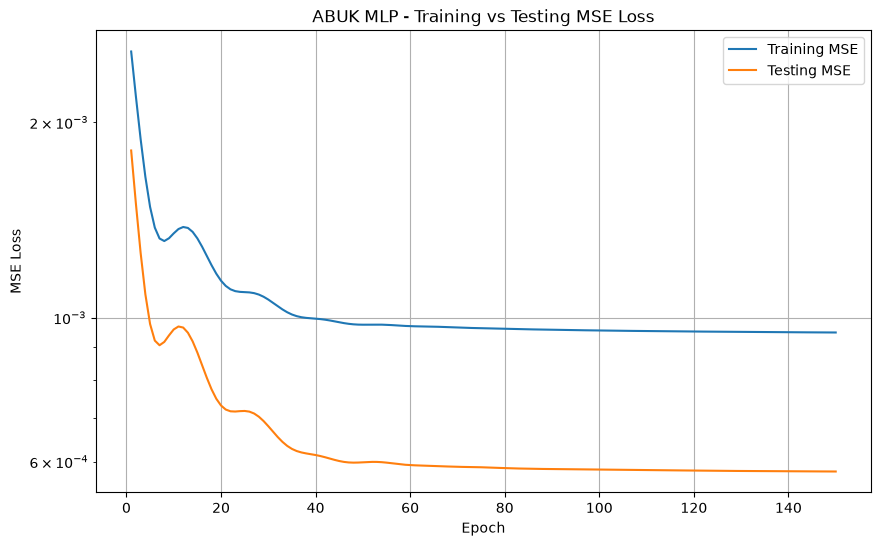

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

epochs = range(1, len(train_losses) + 1)

plt.plot(
    epochs,
    train_losses,
    label="Training MSE"
)

plt.plot(
    epochs,
    test_losses,
    label="Testing MSE"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("ABUK MLP - Training vs Testing MSE Loss")

plt.legend()
plt.yscale('log')

plt.grid(True)

plt.show()


In [21]:
print(f"Final Training MSE: {train_losses[-1]:.8f}")
print(f"Final Testing MSE:  {test_losses[-1]:.8f}")

Final Training MSE: 0.00094851
Final Testing MSE:  0.00057926


In [23]:
import json
import os
import numpy as np

os.makedirs("dashboard/data", exist_ok=True)

model.eval()

with torch.no_grad():
    predicted_returns = model(Xte).squeeze(1)

# Convert tensors to numpy
actual_returns = yte.detach().cpu().numpy()
predicted_returns_np = predicted_returns.detach().cpu().numpy()

# Direction
actual_direction = (actual_returns > 0).astype(int)
predicted_direction = (predicted_returns_np > 0).astype(int)

# Confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    actual_direction,
    predicted_direction
)

results = {
    "symbol": "ABUK",

    "train_mse": float(train_losses[-1]),
    "test_mse": float(test_losses[-1]),

    "train_losses": [
        float(x) for x in train_losses
    ],

    "test_losses": [
        float(x) for x in test_losses
    ],

    "actual_returns": [
        float(x) for x in actual_returns
    ],

    "predicted_returns": [
        float(x) for x in predicted_returns_np
    ],

    "confusion_matrix": cm.tolist()
}

with open(
    "dashboard/data/mlp_results.json",
    "w"
) as f:
    json.dump(results, f)

print("MLP results saved successfully.")

MLP results saved successfully.


In [27]:
model.eval()

with torch.no_grad():
    test_predictions = model(Xte).squeeze()

print("Predictions:", test_predictions[:10])
print("Actual:", yte[:10])

Predictions: tensor([ 0.0007,  0.0005,  0.0008, -0.0003,  0.0018,  0.0017,  0.0010,  0.0039,
         0.0003,  0.0018])
Actual: tensor([-0.0083, -0.0002, -0.0174,  0.0129,  0.0100, -0.0009,  0.0383, -0.0131,
         0.0123,  0.0092])


In [28]:
from pathlib import Path
import json
import numpy as np
import torch

# Create dashboard/data
results_dir = Path("dashboard/data")
results_dir.mkdir(parents=True, exist_ok=True)

results_path = results_dir / "model_results.json"


def to_list(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy().tolist()

    if isinstance(x, np.ndarray):
        return x.tolist()

    return list(x)


results = {
    "train_losses": to_list(train_losses),
    "test_losses": to_list(test_losses),
    "predictions": to_list(test_predictions),
    "actual": to_list(yte),
    "loss_function": "MSE",
    "model": "MLP"
}


with open(results_path, "w") as f:
    json.dump(results, f, indent=2)


print("Saved successfully!")
print(results_path.resolve())

Saved successfully!
D:\EFG\2026-orion\dashboard\data\model_results.json


In [29]:
from pathlib import Path

path = Path("dashboard/data/model_results.json")

print("Exists:", path.exists())
print("Path:", path.resolve())

Exists: True
Path: D:\EFG\2026-orion\dashboard\data\model_results.json
